## 留意事項

* 本資料は教育・情報提供を目的とした検証資料であり、特定の暗号資産や取引手法の売買を推奨するものではありません。
* バックテストは過去データに基づく試算であり、将来の成果を保証しません。
*  手数料・スリッページ・ETF Flowの公表時刻を完全には再現していません。

# 20260813 初心者botter会  
## 〜急落拾いのロングbotの検証〜

![botterkai](botterkai.jpeg)

### 使用ファイル

- `20260813_初心者botter会_急落回復ロング検証.ipynb`
- `event_data.csv`
- `validation_summary.csv`


In [ ]:
from pathlib import Path
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
from IPython.display import display

warnings.filterwarnings("ignore")

BASE = Path.cwd().resolve()
PACKAGE_CANDIDATES = [
    BASE,
    BASE / "event_notebook_20260813_alt_dip_recovery",
    BASE / "basis_kasetsu" / "event_notebook_20260813_alt_dip_recovery",
]
PACKAGE_DIR = next(
    (
        p for p in PACKAGE_CANDIDATES
        if (p / "event_data.csv").exists() and (p / "validation_summary.csv").exists()
    ),
    None,
)
if PACKAGE_DIR is None:
    raise FileNotFoundError("event_data.csv または validation_summary.csv が見つからない状態")

event_data = pd.read_csv(PACKAGE_DIR / "event_data.csv", low_memory=False)
validation_summary = pd.read_csv(PACKAGE_DIR / "validation_summary.csv", low_memory=False)

def summary_part(section):
    return validation_summary[validation_summary["section"].eq(section)].dropna(axis=1, how="all").copy()

candidate_mask = event_data["record_type"].eq("candidate_event")
candidates = event_data[candidate_mask].copy()
for column in ["date", "next_date", "signal_date", "entry_date"]:
    candidates[column] = pd.to_datetime(candidates[column])
positions_reference = candidates[pd.to_numeric(candidates["selected"], errors="coerce").fillna(0).eq(1)].copy()
funnel = summary_part("condition_funnel")
quality = summary_part("data_quality")
btc_raw = event_data[event_data["record_type"].eq("btc_daily")][
    ["date", "symbol", "open", "high", "low", "close", "volume"]
].copy()
btc_raw["date"] = pd.to_datetime(btc_raw["date"])

# data_checker.py（ほへと先生教材）の品質確認処理を配布用Notebookへ内包
DATA_CHECKER_SOURCE = '"""\ndata_checker.py\n===============\nバックテスト前のデータ品質チェック & クレンジングモジュール。\n\n使い方:\n    from data_checker import check_and_clean\n\n    df_clean, report = check_and_clean(df)\n    print(report.summary())\n\n対応データソース: Binance, yfinance, その他任意のOHLCV DataFrame\n"""\n\nfrom __future__ import annotations\n\nimport pandas as pd\nimport numpy as np\nfrom dataclasses import dataclass, field\nfrom typing import Optional\n\n\n# ============================================================\n# 設定\n# ============================================================\n\n# 各データソースの代表的なカラム名 → 内部正規名（open/high/low/close/volume）へのマッピング\nCOLUMN_ALIASES: dict[str, str] = {\n    # 小文字\n    "open": "open", "high": "high", "low": "low", "close": "close", "volume": "volume",\n    # 大文字\n    "Open": "open", "High": "high", "Low": "low", "Close": "close", "Volume": "volume",\n    # yfinance MultiIndex など\n    "Adj Close": "close",\n}\n\n# デフォルト閾値\nDEFAULT_EXTREME_RET        = 0.50  # 1足で50%超の変動 → データ異常とみなす\nDEFAULT_MIN_PRICE          = 0.0   # 価格がこれ以下 → 異常\nDEFAULT_MAX_CONSEC_ZERO_VOL = 3    # 出来高ゼロがこの本数以上連続 → 警告\n\n\n# ============================================================\n# レポートクラス\n# ============================================================\n\n@dataclass\nclass CheckItem:\n    name: str\n    level: str          # "OK" / "WARNING" / "CRITICAL"\n    detail: str\n    n_affected: int = 0\n    fixed: bool = False\n    fix_detail: str = ""\n\n\n@dataclass\nclass CheckReport:\n    source_name: str = ""\n    original_rows: int = 0\n    cleaned_rows: int = 0\n    items: list[CheckItem] = field(default_factory=list)\n\n    def add(self, item: CheckItem) -> None:\n        self.items.append(item)\n\n    # 最悪レベルを返す\n    @property\n    def worst_level(self) -> str:\n        levels = [i.level for i in self.items]\n        if "CRITICAL" in levels:\n            return "CRITICAL"\n        if "WARNING" in levels:\n            return "WARNING"\n        return "OK"\n\n    def summary(self) -> str:\n        lines = [\n            "=" * 60,\n            f"DataChecker レポート  [{self.source_name}]",\n            "=" * 60,\n            f"元データ行数:     {self.original_rows:,}",\n            f"クレンジング後:   {self.cleaned_rows:,}",\n            f"総合判定:         {self.worst_level}",\n            "-" * 60,\n        ]\n        for item in self.items:\n            icon = {"OK": "✅", "WARNING": "⚠️ ", "CRITICAL": "❌"}.get(item.level, "")\n            lines.append(f"{icon} [{item.level:<8}] {item.name}")\n            lines.append(f"           {item.detail}")\n            if item.fixed:\n                lines.append(f"           → 修正済み: {item.fix_detail}")\n        lines.append("=" * 60)\n        return "\\n".join(lines)\n\n\n# ============================================================\n# 内部ユーティリティ\n# ============================================================\n\ndef _normalize_columns(df: pd.DataFrame) -> pd.DataFrame:\n    """カラム名を open/high/low/close/volume に正規化する。"""\n    rename = {}\n    for col in df.columns:\n        normalized = COLUMN_ALIASES.get(str(col))\n        if normalized:\n            rename[col] = normalized\n    return df.rename(columns=rename)\n\n\ndef _infer_freq(df: pd.DataFrame) -> Optional[pd.Timedelta]:\n    """インデックスから時間足（最頻の間隔）を推定する。"""\n    if len(df) < 2:\n        return None\n    diffs = pd.Series(df.index).diff().dropna()\n    return diffs.mode().iloc[0] if not diffs.empty else None\n\n\n# ============================================================\n# メイン関数\n# ============================================================\n\ndef check_and_clean(\n    df: pd.DataFrame,\n    source_name: str = "unknown",\n    extreme_ret_threshold: float = DEFAULT_EXTREME_RET,\n    min_price: float = DEFAULT_MIN_PRICE,\n    max_consec_zero_vol: int = DEFAULT_MAX_CONSEC_ZERO_VOL,\n    auto_fix: bool = True,\n) -> tuple[pd.DataFrame, CheckReport]:\n    """\n    OHLCVデータの品質チェック & クレンジングを実行する。\n\n    Parameters\n    ----------\n    df : pd.DataFrame\n        OHLCVデータ。インデックスは DatetimeIndex 推奨。\n        カラム名は大文字・小文字どちらでも可。\n    source_name : str\n        レポートに表示するデータ名（例: "BTCUSDT_1h_binance"）。\n    extreme_ret_threshold : float\n        この変動率を超えたら「データ異常」とみなす（デフォルト 0.50 = 50%）。\n    min_price : float\n        価格がこれ以下の行を異常とみなす（デフォルト 0）。\n    max_consec_zero_vol : int\n        出来高ゼロがこの本数以上連続したら警告（デフォルト 3）。\n    auto_fix : bool\n        True の場合、WARNING レベルの問題は自動修正する。\n\n    Returns\n    -------\n    df_clean : pd.DataFrame\n        クレンジング済みデータ（問題がなければ元データのコピー）。\n    report : CheckReport\n        チェック結果の詳細レポート。\n    """\n    df = df.copy()\n    df = _normalize_columns(df)\n\n    price_cols = [c for c in ["open", "high", "low", "close"] if c in df.columns]\n    has_volume = "volume" in df.columns\n\n    report = CheckReport(\n        source_name=source_name,\n        original_rows=len(df),\n    )\n\n    # ----------------------------------------------------------\n    # チェック1: 重複インデックス\n    # ----------------------------------------------------------\n    n_dup = df.index.duplicated().sum()\n    if n_dup == 0:\n        report.add(CheckItem("重複行", "OK", f"重複なし"))\n    else:\n        item = CheckItem("重複行", "WARNING", f"{n_dup} 件の重複インデックスを検出", n_affected=n_dup)\n        if auto_fix:\n            df = df[~df.index.duplicated(keep="first")]\n            item.fixed = True\n            item.fix_detail = "最初の出現を残して除去"\n        report.add(item)\n\n    # ----------------------------------------------------------\n    # チェック2: インデックスのソート順\n    # ----------------------------------------------------------\n    if not df.index.is_monotonic_increasing:\n        item = CheckItem("時系列順", "WARNING", "インデックスが昇順になっていない")\n        if auto_fix:\n            df = df.sort_index()\n            item.fixed = True\n            item.fix_detail = "昇順にソート"\n        report.add(item)\n    else:\n        report.add(CheckItem("時系列順", "OK", "昇順で整列済み"))\n\n    # ----------------------------------------------------------\n    # チェック3: 欠損タイムスタンプ（Vol.01ノートブックと同じ reindex 方式）\n    # ※ 24/7取引所（Binance等）向け。CMEなど休場のある取引所では誤検知あり。\n    # ----------------------------------------------------------\n    freq = _infer_freq(df)\n    if freq is not None and isinstance(df.index, pd.DatetimeIndex):\n        expected = pd.date_range(start=df.index.min(), end=df.index.max(), freq=freq)\n        missing_ts = expected.difference(df.index)\n        n_missing = len(missing_ts)\n        if n_missing == 0:\n            report.add(CheckItem("欠損タイムスタンプ", "OK", f"欠損なし（推定時間足: {freq}）"))\n        else:\n            item = CheckItem(\n                "欠損タイムスタンプ", "WARNING",\n                f"{n_missing} 本の足が欠損（推定時間足: {freq}）",\n                n_affected=n_missing,\n            )\n            if auto_fix and price_cols:\n                df = df.reindex(expected)\n                df[price_cols] = df[price_cols].ffill()\n                if has_volume:\n                    df["volume"] = df["volume"].fillna(0)\n                item.fixed = True\n                item.fix_detail = "完全インデックスで reindex → 価格: ffill、出来高: 0補完"\n            report.add(item)\n    else:\n        report.add(CheckItem("欠損タイムスタンプ", "OK", "インデックスが DatetimeIndex でないためスキップ"))\n\n    # ----------------------------------------------------------\n    # チェック4: NaN値\n    # ----------------------------------------------------------\n    n_nan = df[price_cols].isnull().sum().sum() if price_cols else 0\n    if n_nan == 0:\n        report.add(CheckItem("NaN値", "OK", "価格列に NaN なし"))\n    else:\n        item = CheckItem("NaN値", "WARNING", f"価格列に {n_nan} 件の NaN", n_affected=n_nan)\n        if auto_fix and price_cols:\n            df[price_cols] = df[price_cols].ffill()\n            item.fixed = True\n            item.fix_detail = "ffill で補完"\n        report.add(item)\n\n    # ----------------------------------------------------------\n    # チェック5: 価格の妥当性（ゼロ・マイナス）\n    # ----------------------------------------------------------\n    if price_cols:\n        invalid_price = (df[price_cols] <= min_price).any(axis=1)\n        n_inv = invalid_price.sum()\n        if n_inv == 0:\n            report.add(CheckItem("価格妥当性", "OK", f"価格 > {min_price} を確認"))\n        else:\n            item = CheckItem(\n                "価格妥当性", "CRITICAL",\n                f"{n_inv} 行で価格が {min_price} 以下（取引所バグ・データ欠損の可能性）",\n                n_affected=n_inv,\n            )\n            if auto_fix:\n                df.loc[invalid_price, price_cols] = np.nan\n                df[price_cols] = df[price_cols].ffill()\n                item.fixed = True\n                item.fix_detail = "NaN 化 → ffill で補完"\n            report.add(item)\n\n    # ----------------------------------------------------------\n    # チェック6: OHLC整合性（High >= Low）\n    # ----------------------------------------------------------\n    if all(c in df.columns for c in ["high", "low"]):\n        bad_ohlc = (df["high"] < df["low"]).sum()\n        if bad_ohlc == 0:\n            report.add(CheckItem("OHLC整合性", "OK", "high >= low を確認"))\n        else:\n            item = CheckItem(\n                "OHLC整合性", "CRITICAL",\n                f"{bad_ohlc} 行で high < low（データ破損の疑い）",\n                n_affected=bad_ohlc,\n            )\n            if auto_fix:\n                mask = df["high"] < df["low"]\n                df.loc[mask, ["high", "low"]] = np.nan\n                df[["high", "low"]] = df[["high", "low"]].ffill()\n                item.fixed = True\n                item.fix_detail = "該当行を NaN 化 → ffill で補完"\n            report.add(item)\n\n    # ----------------------------------------------------------\n    # チェック7: 急変動（±extreme_ret_threshold 超）\n    # ----------------------------------------------------------\n    if "close" in df.columns:\n        ret = df["close"].pct_change()\n        extreme_mask = ret.abs() > extreme_ret_threshold\n        n_extreme = extreme_mask.sum()\n        if n_extreme == 0:\n            report.add(CheckItem(\n                "急変動チェック", "OK",\n                f"±{extreme_ret_threshold*100:.0f}% 超の変動なし",\n            ))\n        else:\n            pct = extreme_ret_threshold * 100\n            item = CheckItem(\n                "急変動チェック", "CRITICAL",\n                f"{n_extreme} 行で ±{pct:.0f}% 超の変動（取引所障害・フラッシュクラッシュの可能性）",\n                n_affected=n_extreme,\n            )\n            if auto_fix:\n                df.loc[extreme_mask, price_cols] = np.nan\n                df[price_cols] = df[price_cols].ffill()\n                item.fixed = True\n                item.fix_detail = "該当行を NaN 化 → ffill で補完（要目視確認）"\n            report.add(item)\n\n    # ----------------------------------------------------------\n    # チェック8: 出来高ゼロの連続\n    # ----------------------------------------------------------\n    if has_volume:\n        is_zero = (df["volume"] == 0).astype(int)\n        consec = is_zero.groupby((is_zero != is_zero.shift()).cumsum()).transform("sum")\n        max_consec = int(consec.max()) if len(consec) > 0 else 0\n        n_zero = (df["volume"] == 0).sum()\n\n        if max_consec < max_consec_zero_vol:\n            report.add(CheckItem(\n                "出来高ゼロ連続", "OK",\n                f"出来高ゼロ連続の最大: {max_consec} 本（閾値: {max_consec_zero_vol}）",\n            ))\n        else:\n            report.add(CheckItem(\n                "出来高ゼロ連続", "WARNING",\n                f"出来高ゼロが {max_consec} 本連続（取引停止・欠損の可能性）。"\n                f"合計 {n_zero} 本がゼロ。手動確認を推奨。",\n                n_affected=n_zero,\n            ))\n\n    report.cleaned_rows = len(df)\n    return df, report\n'
# 品質確認処理を通常のPythonコードとして定義（動的なexecは使用しない）
from dataclasses import dataclass, field
from typing import Optional

COLUMN_ALIASES: dict[str, str] = {
    "open": "open", "high": "high", "low": "low", "close": "close", "volume": "volume",
    "Open": "open", "High": "high", "Low": "low", "Close": "close", "Volume": "volume",
    "Adj Close": "close",
}
DEFAULT_EXTREME_RET = 0.50
DEFAULT_MIN_PRICE = 0.0
DEFAULT_MAX_CONSEC_ZERO_VOL = 3


@dataclass
class CheckItem:
    name: str
    level: str
    detail: str
    n_affected: int = 0
    fixed: bool = False
    fix_detail: str = ""


@dataclass
class CheckReport:
    source_name: str = ""
    original_rows: int = 0
    cleaned_rows: int = 0
    items: list[CheckItem] = field(default_factory=list)

    def add(self, item: CheckItem) -> None:
        self.items.append(item)

    @property
    def worst_level(self) -> str:
        levels = [item.level for item in self.items]
        if "CRITICAL" in levels:
            return "CRITICAL"
        if "WARNING" in levels:
            return "WARNING"
        return "OK"

    def summary(self) -> str:
        lines = [
            "=" * 60,
            f"DataChecker レポート  [{self.source_name}]",
            "=" * 60,
            f"元データ行数:     {self.original_rows:,}",
            f"クレンジング後:   {self.cleaned_rows:,}",
            f"総合判定:         {self.worst_level}",
            "-" * 60,
        ]
        for item in self.items:
            icon = {"OK": "✅", "WARNING": "⚠️ ", "CRITICAL": "❌"}.get(item.level, "")
            lines.append(f"{icon} [{item.level:<8}] {item.name}")
            lines.append(f"           {item.detail}")
            if item.fixed:
                lines.append(f"           → 修正済み: {item.fix_detail}")
        lines.append("=" * 60)
        return "\n".join(lines)


def _normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    rename = {}
    for column in df.columns:
        normalized = COLUMN_ALIASES.get(str(column))
        if normalized:
            rename[column] = normalized
    return df.rename(columns=rename)


def _infer_freq(df: pd.DataFrame) -> Optional[pd.Timedelta]:
    if len(df) < 2:
        return None
    diffs = pd.Series(df.index).diff().dropna()
    return diffs.mode().iloc[0] if not diffs.empty else None


def check_and_clean(
    df: pd.DataFrame,
    source_name: str = "unknown",
    extreme_ret_threshold: float = DEFAULT_EXTREME_RET,
    min_price: float = DEFAULT_MIN_PRICE,
    max_consec_zero_vol: int = DEFAULT_MAX_CONSEC_ZERO_VOL,
    auto_fix: bool = True,
) -> tuple[pd.DataFrame, CheckReport]:
    df = _normalize_columns(df.copy())
    price_cols = [column for column in ["open", "high", "low", "close"] if column in df.columns]
    has_volume = "volume" in df.columns
    report = CheckReport(source_name=source_name, original_rows=len(df))

    n_dup = df.index.duplicated().sum()
    if n_dup == 0:
        report.add(CheckItem("重複行", "OK", "重複なし"))
    else:
        item = CheckItem("重複行", "WARNING", f"{n_dup} 件の重複インデックスを検出", n_affected=n_dup)
        if auto_fix:
            df = df[~df.index.duplicated(keep="first")]
            item.fixed = True
            item.fix_detail = "最初の出現を残して除去"
        report.add(item)

    if not df.index.is_monotonic_increasing:
        item = CheckItem("時系列順", "WARNING", "インデックスが昇順になっていない")
        if auto_fix:
            df = df.sort_index()
            item.fixed = True
            item.fix_detail = "昇順にソート"
        report.add(item)
    else:
        report.add(CheckItem("時系列順", "OK", "昇順で整列済み"))

    freq = _infer_freq(df)
    if freq is not None and isinstance(df.index, pd.DatetimeIndex):
        expected = pd.date_range(start=df.index.min(), end=df.index.max(), freq=freq)
        missing_ts = expected.difference(df.index)
        n_missing = len(missing_ts)
        if n_missing == 0:
            report.add(CheckItem("欠損タイムスタンプ", "OK", f"欠損なし（推定時間足: {freq}）"))
        else:
            item = CheckItem(
                "欠損タイムスタンプ", "WARNING",
                f"{n_missing} 本の足が欠損（推定時間足: {freq}）",
                n_affected=n_missing,
            )
            if auto_fix and price_cols:
                df = df.reindex(expected)
                df[price_cols] = df[price_cols].ffill()
                if has_volume:
                    df["volume"] = df["volume"].fillna(0)
                item.fixed = True
                item.fix_detail = "完全インデックスで reindex → 価格: ffill、出来高: 0補完"
            report.add(item)
    else:
        report.add(CheckItem("欠損タイムスタンプ", "OK", "インデックスが DatetimeIndex でないためスキップ"))

    n_nan = df[price_cols].isnull().sum().sum() if price_cols else 0
    if n_nan == 0:
        report.add(CheckItem("NaN値", "OK", "価格列に NaN なし"))
    else:
        item = CheckItem("NaN値", "WARNING", f"価格列に {n_nan} 件の NaN", n_affected=n_nan)
        if auto_fix and price_cols:
            df[price_cols] = df[price_cols].ffill()
            item.fixed = True
            item.fix_detail = "ffill で補完"
        report.add(item)

    if price_cols:
        invalid_price = (df[price_cols] <= min_price).any(axis=1)
        n_invalid = invalid_price.sum()
        if n_invalid == 0:
            report.add(CheckItem("価格妥当性", "OK", f"価格 > {min_price} を確認"))
        else:
            item = CheckItem(
                "価格妥当性", "CRITICAL",
                f"{n_invalid} 行で価格が {min_price} 以下（取引所バグ・データ欠損の可能性）",
                n_affected=n_invalid,
            )
            if auto_fix:
                df.loc[invalid_price, price_cols] = np.nan
                df[price_cols] = df[price_cols].ffill()
                item.fixed = True
                item.fix_detail = "NaN 化 → ffill で補完"
            report.add(item)

    if all(column in df.columns for column in ["high", "low"]):
        bad_ohlc = (df["high"] < df["low"]).sum()
        if bad_ohlc == 0:
            report.add(CheckItem("OHLC整合性", "OK", "high >= low を確認"))
        else:
            item = CheckItem(
                "OHLC整合性", "CRITICAL",
                f"{bad_ohlc} 行で high < low（データ破損の疑い）",
                n_affected=bad_ohlc,
            )
            if auto_fix:
                mask = df["high"] < df["low"]
                df.loc[mask, ["high", "low"]] = np.nan
                df[["high", "low"]] = df[["high", "low"]].ffill()
                item.fixed = True
                item.fix_detail = "該当行を NaN 化 → ffill で補完"
            report.add(item)

    if "close" in df.columns:
        returns = df["close"].pct_change()
        extreme_mask = returns.abs() > extreme_ret_threshold
        n_extreme = extreme_mask.sum()
        if n_extreme == 0:
            report.add(CheckItem(
                "急変動チェック", "OK",
                f"±{extreme_ret_threshold * 100:.0f}% 超の変動なし",
            ))
        else:
            threshold_pct = extreme_ret_threshold * 100
            item = CheckItem(
                "急変動チェック", "CRITICAL",
                f"{n_extreme} 行で ±{threshold_pct:.0f}% 超の変動（取引所障害・フラッシュクラッシュの可能性）",
                n_affected=n_extreme,
            )
            if auto_fix:
                df.loc[extreme_mask, price_cols] = np.nan
                df[price_cols] = df[price_cols].ffill()
                item.fixed = True
                item.fix_detail = "該当行を NaN 化 → ffill で補完（要目視確認）"
            report.add(item)

    if has_volume:
        is_zero = (df["volume"] == 0).astype(int)
        consecutive = is_zero.groupby((is_zero != is_zero.shift()).cumsum()).transform("sum")
        max_consecutive = int(consecutive.max()) if len(consecutive) > 0 else 0
        n_zero = (df["volume"] == 0).sum()
        if max_consecutive < max_consec_zero_vol:
            report.add(CheckItem(
                "出来高ゼロ連続", "OK",
                f"出来高ゼロ連続の最大: {max_consecutive} 本（閾値: {max_consec_zero_vol}）",
            ))
        else:
            report.add(CheckItem(
                "出来高ゼロ連続", "WARNING",
                f"出来高ゼロが {max_consecutive} 本連続（取引停止・欠損の可能性）。"
                f"合計 {n_zero} 本がゼロ。手動確認を推奨。",
                n_affected=n_zero,
            ))

    report.cleaned_rows = len(df)
    return df, report

btc_input = btc_raw.set_index("date")[["open", "high", "low", "close", "volume"]]
btc_daily, btc_report = check_and_clean(
    btc_input,
    source_name="BTCUSDT_1d_event_notebook",
    auto_fix=False,
)
print(btc_report.summary())
if btc_report.worst_level == "CRITICAL":
    raise RuntimeError("BTC日足のデータ品質がCRITICALのため検証中断")

DEVELOPMENT_START = pd.Timestamp("2021-04-01")
DEVELOPMENT_END = pd.Timestamp("2026-06-02")
FORWARD_START = pd.Timestamp("2026-06-03")
FORWARD_END = pd.Timestamp("2026-08-12")
COST_BPS = 10.0
TOP_N = 2

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 170
plt.rcParams["axes.unicode_minus"] = False
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for font in ["Hiragino Sans", "YuGothic", "Meiryo", "AppleGothic", "DejaVu Sans"]:
    if font in available_fonts:
        plt.rcParams["font.family"] = [font]
        break

COLORS = {"bot": "#147d68", "btc": "#8998ad", "loss": "#c34b43", "accent": "#3766a6"}
print("Package:", PACKAGE_DIR)
print("Candidate events:", f"{len(candidates):,}")
print("BTC daily rows:", f"{len(btc_daily):,}")
print("Distributed CSV files: 2")

## 0. 今日の流れ

```text
問い
↓
仮説
↓
検証ロジック
↓
使用データ・評価方法
↓
検証結果
↓
仮説判定・実運用判定
↓
次の検証
```

## 1. 問い

### 急落したアルトコインは、翌日に反発するのか

```text
大きな下落
↓
一時的な売られすぎ
↓
翌日の反発？
```


## 2. 仮説

### 上昇トレンド中に急落し、日足で回復した銘柄は翌日も反発が続きやすい。

```text
上昇トレンド
＋
−7〜−10%の急落
＋
50%以上の回復確認
＋
高い流動性
↓
翌日の反発継続？
```


## 3. 検証ロジック

| 項目 | 条件 |
|---|---|
| 対象 | Binance USDⓈ-M USDT無期限アルト |
| 流動性 | 上場90日以上、前日まで30日中央値1,000万USDT以上 |
| トレンド | BTCと対象銘柄の終値が200日SMAより上 |
| 急落 | 当日安値が前日終値比 −7〜−10% |
| 回復 | 下落幅を日足終値で50%以上回復 |
| 選択 | 前日まで30日流動性の上位2銘柄 |
| 売買 | 翌日始値ロング、同日終値決済 |
| 配分 | 最大2銘柄への均等配分 |
| コスト | 往復10bp |

**回復率**

```text
(当日終値 − 当日安値) ÷ (前日終値 − 当日安値)
```

50%以上は反発の強さを競うランキングではなく、落下停止を確認する通過条件

In [2]:
# 候補CSVは、トレンド・急落・回復・流動性の通過後データ
# 前日までの30日流動性で各日上位2銘柄を選択
selected = candidates.sort_values(
    ["date", "prior_median_notional_30d", "max_drop", "symbol"],
    ascending=[True, False, True, True],
).copy()
selected["selection_rank"] = selected.groupby("date").cumcount() + 1
selected = selected[selected["selection_rank"] <= TOP_N].copy()
selected["signal_date"] = selected["date"]
selected["entry_date"] = selected["next_date"]
selected["gross_ret"] = selected["next_open_close_ret"]
selected["net_ret"] = selected["gross_ret"] - COST_BPS / 10_000

development = selected[
    (selected["signal_date"] >= DEVELOPMENT_START)
    & (selected["entry_date"] <= DEVELOPMENT_END)
].copy()
forward = selected[
    (selected["signal_date"] >= FORWARD_START)
    & (selected["entry_date"] <= FORWARD_END)
].copy()

check_cols = ["entry_date", "symbol", "selection_rank", "net_ret"]
reference = positions_reference[positions_reference["period"].eq("development")][check_cols]
rebuilt = development[check_cols]
assert len(rebuilt) == len(reference)
assert np.allclose(
    rebuilt.sort_values(["entry_date", "symbol"])["net_ret"],
    reference.sort_values(["entry_date", "symbol"])["net_ret"],
)

print("Rebuilt positions:", len(development))
print("Active days:", development["entry_date"].nunique())
print("Forward positions:", len(forward))
display(development[["signal_date", "entry_date", "symbol", "max_drop", "recovery_raw", "prior_median_notional_30d", "net_ret"]].head())

Rebuilt positions: 545
Active days: 355
Forward positions: 0


,signal_date,entry_date,symbol,max_drop,recovery_raw,prior_median_notional_30d,net_ret
297,2021-08-14,2021-08-15,AXS,-0.079190,0.500894,2.023086e+09,0.001655
298,2021-08-15,2021-08-16,AXS,-0.070796,1.037500,1.783498e+09,-0.025562
56,2021-08-15,2021-08-16,ADA,-0.073102,0.868832,5.731541e+08,-0.045304
266,2021-08-22,2021-08-23,AVAX,-0.072895,1.012543,7.450497e+07,0.059927
2093,2021-08-24,2021-08-25,ZEN,-0.071461,1.034356,3.328565e+07,0.055022


結果:

- 参照結果と一致する545ポジション
- 取引日355日
- 未使用期間の選定ゼロ
- 当日確定情報だけによるランキング

## 4. 使用データ

| 項目 | 内容 |
|---|---|
| 市場 | Binance USDⓈ-M |
| 足種 | 日足OHLCV |
| 対象 | 357銘柄 |
| 開発期間 | 2021-04-01〜2026-06-02 |
| 未使用期間 | 2026-06-03〜2026-08-12 |


In [3]:
quality_summary = pd.DataFrame({
    "項目": ["検査銘柄", "構造的CRITICAL", "急変動CRITICAL", "欠損タイムスタンプ"],
    "結果": [
        quality["symbol"].nunique(),
        quality["critical_items"].fillna("").apply(lambda x: bool(x) and x != "急変動チェック").sum(),
        quality["critical_items"].fillna("").eq("急変動チェック").sum(),
        int(quality["missing_timestamps"].sum()),
    ],
})
display(quality_summary)

,項目,結果
0,検査銘柄,357
1,構造的CRITICAL,0
2,急変動CRITICAL,188
3,欠損タイムスタンプ,0


## 5. 評価方法

### 主な評価軸

- 累積リターン
- 最大ドローダウン
- 取引回数と1取引平均
- 年別成績
- BTC HODLとの比較
- 未使用期間での再現性

### 判定の分離

```text
開発期間で仮説に合う結果か
≠
未使用期間で再現したか
≠
実運用できる水準か
```

HODL超過を必須条件としない一方、現金待機の代わりにDDと市場滞在率の改善を求める評価

In [4]:
def daily_strategy_returns(positions, start, end):
    dates = pd.date_range(start, end, freq="D")
    return positions.groupby("entry_date")["net_ret"].mean().reindex(dates, fill_value=0.0)

def btc_hodl_returns(start, end):
    sample = btc_daily.loc[start:end].copy()
    returns = sample["close"].pct_change().fillna(0.0)
    returns.iloc[0] = sample.iloc[0]["close"] / sample.iloc[0]["open"] - 1.0
    return returns.reindex(pd.date_range(start, end), fill_value=0.0)

def metrics(returns, active_returns=None):
    curve = (1 + returns).cumprod()
    dd = curve / curve.cummax() - 1
    active = returns[returns.ne(0)] if active_returns is None else active_returns
    return {
        "累積リターン": (curve.iloc[-1] - 1) * 100,
        "最大DD": dd.min() * 100,
        "取引日": int((returns != 0).sum()),
        "平均損益": active.mean() * 100 if len(active) else np.nan,
    }

bot_daily = daily_strategy_returns(development, DEVELOPMENT_START, DEVELOPMENT_END)
btc_returns = btc_hodl_returns(DEVELOPMENT_START, DEVELOPMENT_END)
bot_active = development.groupby("entry_date")["net_ret"].mean()

result_table = pd.DataFrame([
    {"対象": "急落回復ロング", **metrics(bot_daily, bot_active)},
    {"対象": "BTC HODL", **metrics(btc_returns)},
])
display(result_table.round(2))

,対象,累積リターン,最大DD,取引日,平均損益
0,急落回復ロング,148.81,-56.84,355,0.57
1,BTC HODL,15.56,-76.67,1889,0.05


## 6. 検証結果

### 開発期間

```text
累積リターン    +148.8%
最大DD           −56.8%
ポジション数       545回
取引日数            355日
1取引平均          +0.28%
取引勝率             47.5%
BTC HODL           +15.6%
```

最終利益はプラス。一方、運用中に約56.8%の下落とピーク後の大幅な失速

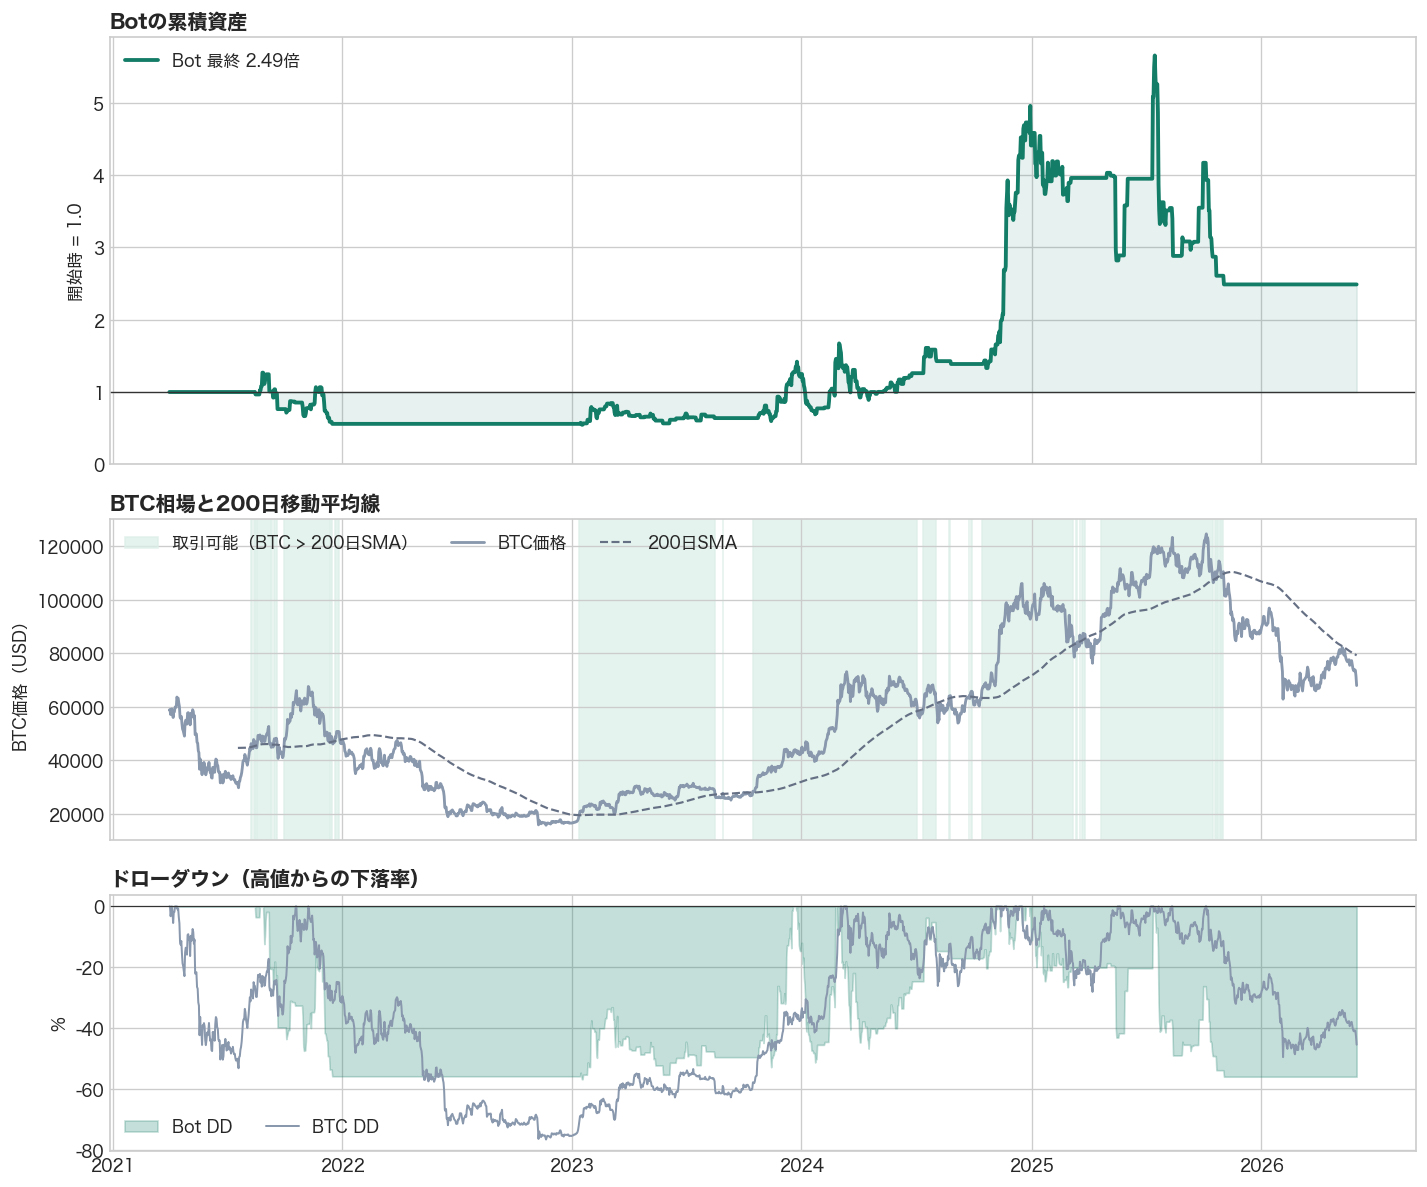

In [5]:
bot_curve = (1 + bot_daily).cumprod()
btc_curve = (1 + btc_returns).cumprod()
btc_price = btc_daily["close"].reindex(bot_curve.index)
btc_sma200 = btc_daily["close"].rolling(200, min_periods=200).mean().reindex(bot_curve.index)
btc_bull = btc_price > btc_sma200

# 情報を重ねず、Bot・BTC相場・ドローダウンの3段に分離
fig, axes = plt.subplots(
    3, 1, figsize=(12, 10), sharex=True,
    gridspec_kw={"height_ratios": [2.0, 1.5, 1.2]},
)

# 1. Botの運用結果
axes[0].plot(
    bot_curve.index, bot_curve,
    color=COLORS["bot"], lw=2.3,
    label=f"Bot 最終 {bot_curve.iloc[-1]:.2f}倍",
)
axes[0].axhline(1.0, color="#333", lw=0.8)
axes[0].fill_between(bot_curve.index, 1.0, bot_curve, color=COLORS["bot"], alpha=0.10)
axes[0].set_title("Botの累積資産", loc="left", weight="bold")
axes[0].set_ylabel("開始時 = 1.0")
axes[0].set_ylim(bottom=0)
axes[0].legend(loc="upper left")

# 2. BTC価格と相場判定
axes[1].fill_between(
    btc_price.index, 0, 1,
    where=btc_bull,
    transform=axes[1].get_xaxis_transform(),
    color="#dcefe8", alpha=0.75,
    label="取引可能（BTC > 200日SMA）", zorder=0,
)
axes[1].plot(btc_price.index, btc_price, color=COLORS["btc"], lw=1.7, label="BTC価格", zorder=2)
axes[1].plot(btc_sma200.index, btc_sma200, color="#667085", lw=1.3, ls="--", label="200日SMA", zorder=2)
axes[1].set_title("BTC相場と200日移動平均線", loc="left", weight="bold")
axes[1].set_ylabel("BTC価格（USD）")
axes[1].legend(loc="upper left", ncol=3)

# 3. 高値からの下落率
bot_dd = bot_curve / bot_curve.cummax() - 1
btc_dd = btc_curve / btc_curve.cummax() - 1
axes[2].fill_between(bot_dd.index, bot_dd * 100, 0, color=COLORS["bot"], alpha=0.25, label="Bot DD")
axes[2].plot(btc_dd.index, btc_dd * 100, color=COLORS["btc"], lw=1.2, label="BTC DD")
axes[2].axhline(0, color="#333", lw=0.7)
axes[2].set_title("ドローダウン（高値からの下落率）", loc="left", weight="bold")
axes[2].set_ylabel("%")
axes[2].legend(loc="lower left", ncol=2)

plt.tight_layout()
plt.show()

結果:

- 開発期間の最終資産2.49倍
- BTC HODLの最終資産1.16倍
- HODLより小さいが、依然として大きい最大DD
- 2025年以降の資産曲線失速

## 7. 年別成績

全期間のプラスと、毎年機能する再現性の区別

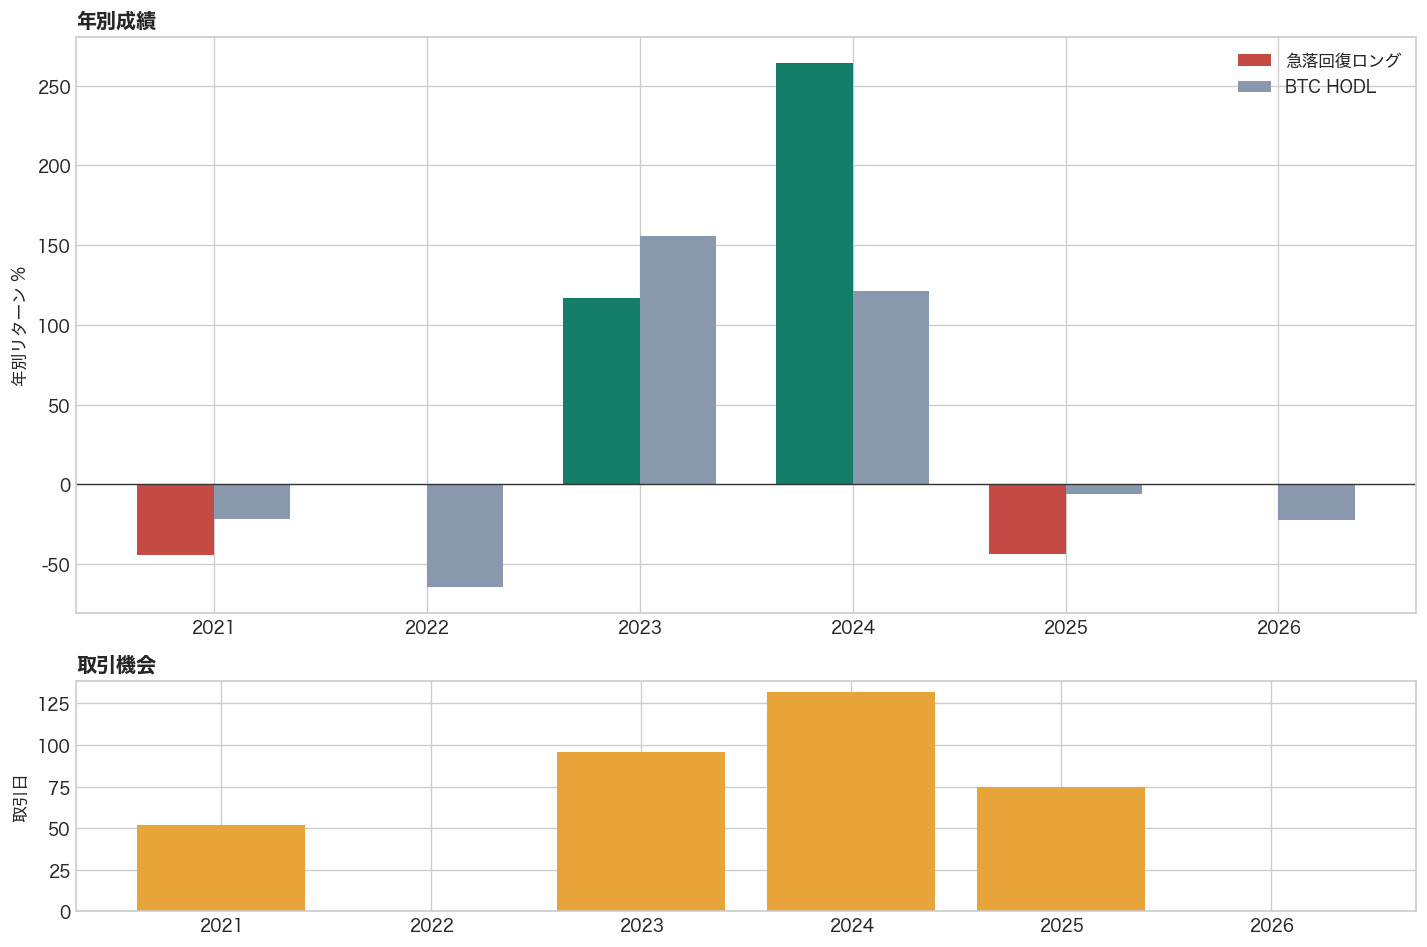

,年,Bot,BTC HODL,取引日
0,2021,-44.06,-21.43,52
1,2022,0.00,-64.21,0
2,2023,116.57,155.87,96
3,2024,264.05,121.08,132
4,2025,-43.59,-6.35,75
5,2026,0.00,-22.42,0


In [6]:
rows = []
for year in range(2021, 2027):
    start = max(DEVELOPMENT_START, pd.Timestamp(year=year, month=1, day=1))
    end = min(DEVELOPMENT_END, pd.Timestamp(year=year, month=12, day=31))
    if start > end:
        continue
    bot_year = bot_daily.loc[start:end]
    btc_year = btc_returns.loc[start:end]
    rows.append({
        "年": year,
        "Bot": ((1 + bot_year).prod() - 1) * 100,
        "BTC HODL": ((1 + btc_year).prod() - 1) * 100,
        "取引日": development[development["entry_date"].between(start, end)]["entry_date"].nunique(),
    })
yearly = pd.DataFrame(rows)

x = np.arange(len(yearly))
width = 0.36
fig, axes = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={"height_ratios": [3, 1.2]})
bot_colors = [COLORS["loss"] if v < 0 else COLORS["bot"] if v > 0 else "#b8bec8" for v in yearly["Bot"]]
axes[0].bar(x - width/2, yearly["Bot"], width, color=bot_colors, label="急落回復ロング")
axes[0].bar(x + width/2, yearly["BTC HODL"], width, color=COLORS["btc"], label="BTC HODL")
axes[0].axhline(0, color="#333", lw=0.8)
axes[0].set_xticks(x, yearly["年"])
axes[0].set_ylabel("年別リターン %")
axes[0].set_title("年別成績", loc="left", weight="bold")
axes[0].legend()
axes[1].bar(x, yearly["取引日"], color="#e7a43b")
axes[1].set_xticks(x, yearly["年"])
axes[1].set_ylabel("取引日")
axes[1].set_title("取引機会", loc="left", weight="bold")
plt.tight_layout()
plt.show()
display(yearly.round(2))

結果:

- 利益の中心となった2023〜2024年
- 大きな損失となった2021年・2025年
- トレンド条件による2022年・2026年の取引ゼロ
- 相場局面に依存する成績

## 8. 未使用期間

### 2026-06-03〜2026-08-12

```text
取引回数      0回
累積損益      0.0%
BTC HODL     −4.9%
```

BTCが200日SMAを下回り、全日見送り。弱気相場では買わない設計との一致。ただし売買ロジックの再現性は未確認

,stage,symbol_days,signal_dates
13,適格ユニバース,4696.0,70.0
14,BTCが200日線より上,0.0,0.0
15,さらにアルトも200日線より上,0.0,0.0
16,さらに日中-7〜-10%,0.0,0.0
17,さらに50%以上回復,0.0,0.0


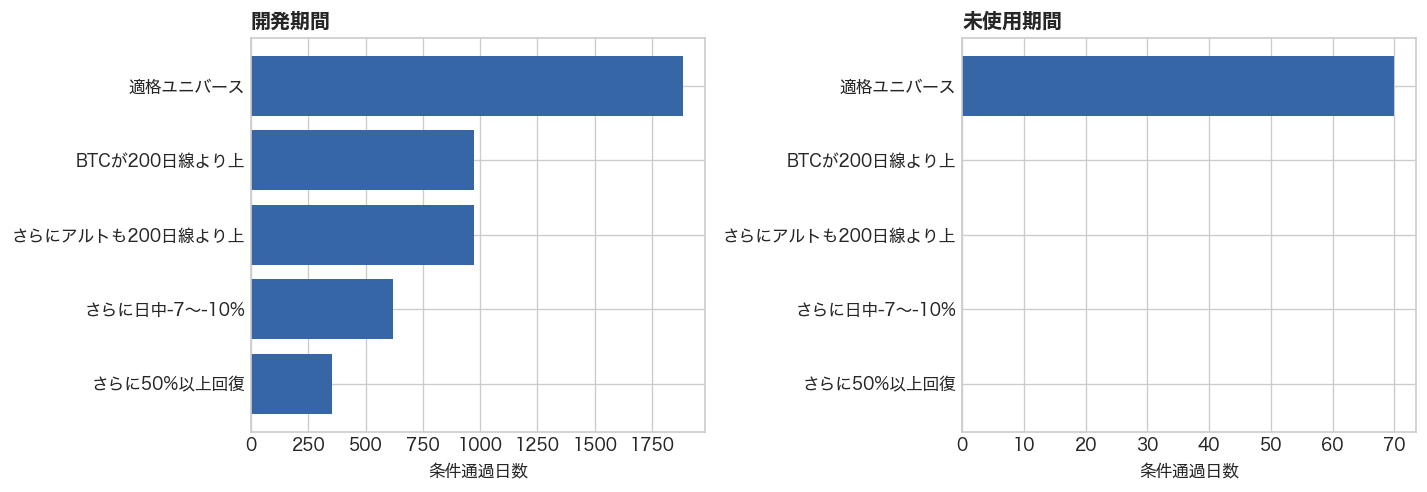

In [7]:
fwd = funnel[funnel["period"].eq("forward")][["stage", "symbol_days", "signal_dates"]]
dev = funnel[funnel["period"].eq("development")][["stage", "symbol_days", "signal_dates"]]
display(fwd)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, table, title in [(axes[0], dev, "開発期間"), (axes[1], fwd, "未使用期間")]:
    ax.barh(table["stage"], table["signal_dates"], color=COLORS["accent"])
    ax.invert_yaxis()
    ax.set_title(title, loc="left", weight="bold")
    ax.set_xlabel("条件通過日数")
plt.tight_layout()
plt.show()

## 9. 仮説の判定

### 一部支持

**支持材料**

- 開発期間の累積リターン+148.8%
- 単純な急落買いより改善した回復確認と流動性条件
- 弱気相場を避ける200日SMA条件との整合

**反証・留保**

- 最大DD −56.8%
- 2021年・2025年の大幅損失
- 未使用期間の取引ゼロ
- 開発期間での条件探索による過剰適合の可能性

開発期間で筋の通る結果。未知の相場での再現は未確認

## 10. 実運用の判定

### 見送り

```text
仮説の一部支持
≠
実運用可能
```

**見送り理由**

- 許容困難な最大DD −56.8%
- 利益の大きな年偏り
- 未使用取引サンプルの不足
- 生存者バイアスを含むデータ上の制約

完成したbotではなく、ルール固定後の継続観測に値する仮説

## 11. 次の検証

1. ルールを変えない未使用期間の継続観測
2. 未使用取引30〜50件の蓄積
3. 最大DDを抑える撤退条件の別仮説化

パラメータの再調整より先に、固定ルールの未知データ蓄積

<div style="break-before: page; page-break-before: always;"></div>

---
## 免責事項

* 本資料は教育・情報提供を目的としており、売買を推奨するものではありません。
* バックテスト結果は過去データに基づく試算であり、将来の成果を保証しません。
* 暗号資産は大きく価格変動する可能性があります。
* 手数料、スリッページ、税金、約定遅延、データ訂正等を完全には反映していません。
* 本資料の利用により生じたいかなる損害についても責任を負いません。
